# M4.Ex1: Housing Prices Model (PyCaret)

## Exercise

Apply PyCaret regression on the **California Housing Dataset**:

- Setup
- Compare Models
- Analyze Model
- Predictions
- Save the model

## Step 0: Install & Patch PyCaret

> ⚠️ **Run this cell first. Then go to Runtime → Restart session. Then run all remaining cells from Step 1 onward.**
>
> PyCaret hard-blocks Python 3.12 in its source code even though it runs fine on it. The `sed` command patches that single-line check.

In [1]:
# Install PyCaret
!pip install pycaret -q

# Patch the Python version gate: change (3, 12) to (3, 99) so import is allowed
!sed -i 's/elif sys.version_info >= (3, 12):/elif sys.version_info >= (3, 99):/' \
    /usr/local/lib/python3.12/dist-packages/pycaret/__init__.py



## Step 1: Load the Data

California Housing dataset loaded from a public GitHub URL.
Target variable: `median_house_value`.
Features include geographic coordinates, housing stats, and ocean proximity.

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

print(df.shape)
df.head()

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
# Summary statistics
df.describe()

## Step 2: Setup

`setup()` automatically handles:
- Train/test split (80/20)
- Missing value imputation (`total_bedrooms` has 207 nulls)
- Encoding of `ocean_proximity` (categorical)
- Z-score normalization of numeric features

In [4]:
from pycaret.regression import (
    setup, compare_models, pull,
    plot_model, predict_model,
    save_model, load_model
)

reg = setup(
    data=df,
    target='median_house_value',
    session_id=42,               # for reproducibility
    train_size=0.8,              # 80% train, 20% test
    normalize=True,              # scale numeric features
    normalize_method='zscore',
    verbose=True
)

,Description,Value
0,Session id,42
1,Target,median_house_value
2,Target type,Regression
3,Original data shape,"(20640, 10)"
4,Transformed data shape,"(20640, 14)"
5,Transformed train set shape,"(16512, 14)"
6,Transformed test set shape,"(4128, 14)"
7,Numeric features,8
8,Categorical features,1
9,Rows with missing values,1.0%


## Step 3: Compare Models

`compare_models()` trains all available regressors using cross-validation and ranks them by R².
We keep the top 3 for further analysis.

In [5]:
best_models = compare_models(n_select=3, sort='R2')

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,31994.4698,2276914848.9329,47688.5654,0.8296,0.2346,0.1784,1.3040
rf,Random Forest Regressor,31879.7823,2389454637.5643,48852.5011,0.8211,0.2366,0.1775,13.8840
et,Extra Trees Regressor,34546.3010,2697478489.2996,51914.4386,0.7981,0.2484,0.1914,5.3580
gbr,Gradient Boosting Regressor,38259.4015,3021826600.1471,54935.9599,0.7739,0.2698,0.2152,3.1100
knn,K Neighbors Regressor,41212.9375,3780467353.6000,61451.4555,0.7170,0.2879,0.2214,0.3820
dt,Decision Tree Regressor,43216.7861,4615999834.4968,67910.3758,0.6543,0.3245,0.2372,0.2610
lar,Least Angle Regression,49662.1441,4711560936.5901,68595.3957,0.6475,0.3812,0.2858,0.0840
br,Bayesian Ridge,49659.6353,4711459062.4210,68594.8550,0.6475,0.3798,0.2857,0.1120
llar,Lasso Least Angle Regression,49662.0767,4711554171.8066,68595.3667,0.6475,0.3811,0.2858,0.1010
ridge,Ridge Regression,49661.3700,4711520542.2727,68595.1617,0.6475,0.3807,0.2858,0.0880


Processing:   0%|          | 0/83 [00:00<?, ?it/s]

In [6]:
# Full comparison table
comparison_df = pull()
print(comparison_df)

                                    Model         MAE           MSE  \
lightgbm  Light Gradient Boosting Machine  31994.4698  2.276915e+09   
rf                Random Forest Regressor  31879.7823  2.389455e+09   
et                  Extra Trees Regressor  34546.3010  2.697478e+09   
gbr           Gradient Boosting Regressor  38259.4015  3.021827e+09   
knn                 K Neighbors Regressor  41212.9375  3.780467e+09   
dt                Decision Tree Regressor  43216.7861  4.616000e+09   
lar                Least Angle Regression  49662.1441  4.711561e+09   
br                         Bayesian Ridge  49659.6353  4.711459e+09   
llar         Lasso Least Angle Regression  49662.0767  4.711554e+09   
ridge                    Ridge Regression  49661.3700  4.711521e+09   
lasso                    Lasso Regression  49662.0850  4.711555e+09   
lr                      Linear Regression  49662.1441  4.711561e+09   
huber                     Huber Regressor  48455.5601  4.811016e+09   
par   

In [7]:
# Select the top-ranked model
best_model = best_models[0]
print("Best model:", type(best_model).__name__)

Best model: LGBMRegressor


## Step 4: Analyze Model

| Plot | What it shows |
|---|---|
| `residuals` | Errors should be randomly distributed around 0 |
| `error` | Predicted vs Actual — closer to diagonal = better |
| `feature` | Which features matter most |
| `learning` | Diagnoses under/overfitting |

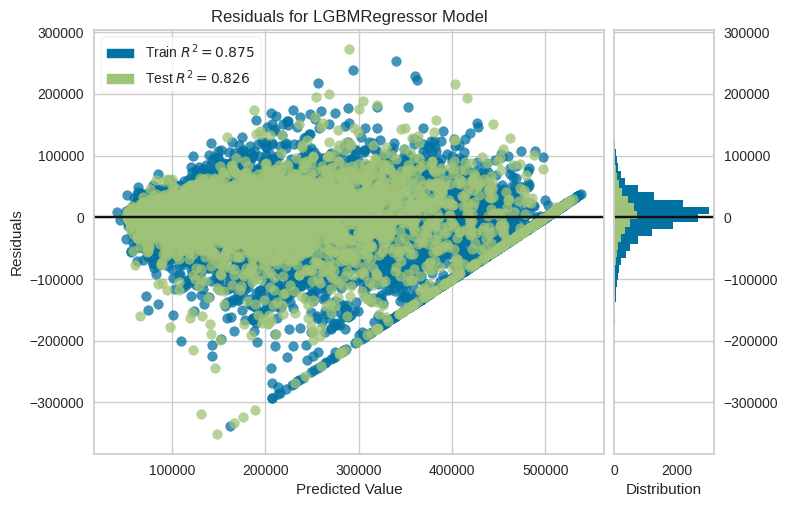

In [8]:
plot_model(best_model, plot='residuals')

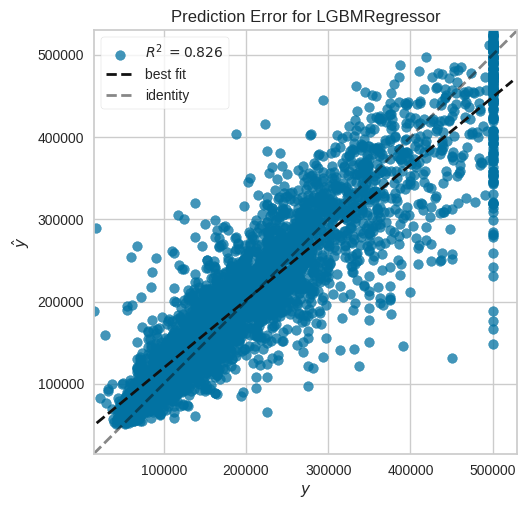

In [9]:
plot_model(best_model, plot='error')

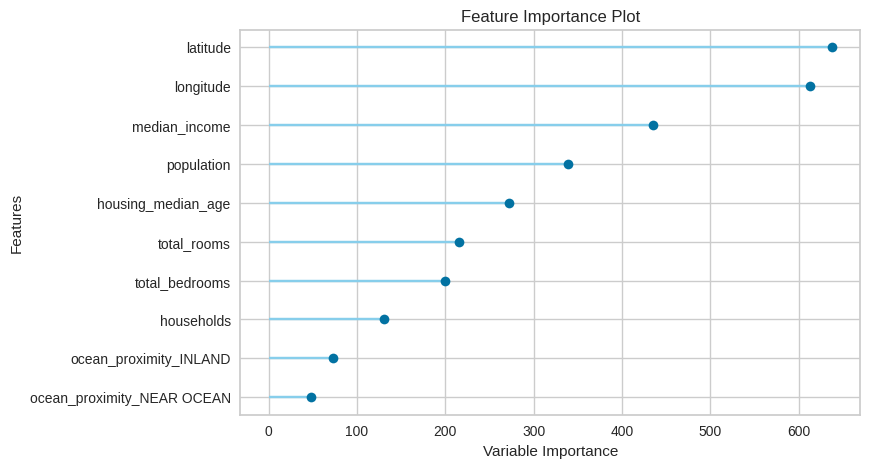

In [10]:
plot_model(best_model, plot='feature')

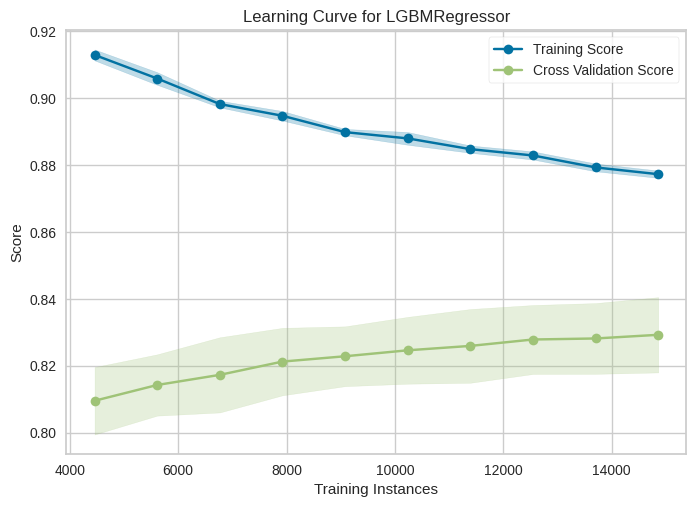

In [11]:
plot_model(best_model, plot='learning')

## Step 5: Predictions

### 5a. Evaluate on the held-out test set

In [12]:
predictions = predict_model(best_model)
predictions[['median_house_value', 'prediction_label']].head(10)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,32149.4939,2279656852.1107,47745.7522,0.8260,0.2384,0.1833


,median_house_value,prediction_label
20046,47700.0,59236.272508
3024,45800.0,69649.777847
15663,500001.0,468847.627832
20484,218600.0,249126.634223
9814,278000.0,314462.456538
13311,158700.0,166610.854692
7113,198200.0,315680.745049
7668,157500.0,228618.420422
18246,340000.0,315168.237313
5723,446600.0,472242.746240


In [13]:
test_metrics = pull()
print(test_metrics)

                             Model         MAE           MSE        RMSE  \
0  Light Gradient Boosting Machine  32149.4939  2.279657e+09  47745.7522   

      R2   RMSLE    MAPE  
0  0.826  0.2384  0.1833  


### 5b. Predict on a new unseen data point

Column names must exactly match the original dataset.

In [14]:
new_data = pd.DataFrame({
    'longitude':           [-118.0],
    'latitude':            [34.0],
    'housing_median_age':  [20.0],
    'total_rooms':         [3000.0],
    'total_bedrooms':      [500.0],
    'population':          [800.0],
    'households':          [400.0],
    'median_income':       [5.0],
    'ocean_proximity':     ['INLAND']
})

new_prediction = predict_model(best_model, data=new_data)
print("Predicted median house value: $", round(new_prediction['prediction_label'].values[0], 2))

Predicted median house value: $ 267093.38


## Step 6: Save & Load the Model

`save_model()` serializes the full pipeline (preprocessing + trained model) into a `.pkl` file.
This means you can reload and predict without retraining.

In [15]:
save_model(best_model, 'california_housing_model')
print("Model saved as 'california_housing_model.pkl'")

Transformation Pipeline and Model Successfully Saved
Model saved as 'california_housing_model.pkl'


In [16]:
# Reload and verify predictions match
loaded_model = load_model('california_housing_model')

verify = predict_model(loaded_model, data=new_data)
print("Prediction from loaded model: $", round(verify['prediction_label'].values[0], 2))

Transformation Pipeline and Model Successfully Loaded


Prediction from loaded model: $ 267093.38


## Summary

| Step | PyCaret Function | Purpose |
|---|---|---|
| Setup | `setup()` | Define target, split data, configure preprocessing |
| Compare | `compare_models()` | Benchmark all algorithms via cross-validation |
| Analyze | `plot_model()` | Inspect residuals, errors, and feature importance |
| Predict | `predict_model()` | Score test set or new data |
| Save | `save_model()` | Persist full pipeline to disk |

**Key observations:**
- `median_income` is the strongest predictor of house prices.
- `latitude` and `longitude` capture the coastal price premium.
- `ocean_proximity` adds useful categorical geographic context.
- `total_bedrooms` had missing values — PyCaret handled imputation automatically in `setup()`.